In [62]:
import tensorflow as tf
print(tf.__version__)


2.18.0


In [63]:
# Import some Basic Libraries

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
df = pd.read_csv('Bank Term Deposit .csv')

In [66]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [67]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [68]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4521.0,41.170095,10.576211,19.0,33.0,39.0,49.0,87.0
balance,4521.0,1422.657819,3009.638142,-3313.0,69.0,444.0,1480.0,71188.0
day,4521.0,15.915284,8.247667,1.0,9.0,16.0,21.0,31.0
duration,4521.0,263.961292,259.856633,4.0,104.0,185.0,329.0,3025.0
campaign,4521.0,2.793630,3.109807,1.0,1.0,2.0,3.0,50.0
pdays,4521.0,39.766645,100.121124,-1.0,-1.0,-1.0,-1.0,871.0
previous,4521.0,0.542579,1.693562,0.0,0.0,0.0,0.0,25.0


In [69]:
df.describe(include = 'O').T

,count,unique,top,freq
job,4521,12,management,969
marital,4521,3,married,2797
education,4521,4,secondary,2306
default,4521,2,no,4445
housing,4521,2,yes,2559
loan,4521,2,no,3830
contact,4521,3,cellular,2896
month,4521,12,may,1398
poutcome,4521,4,unknown,3705
y,4521,2,no,4000


In [70]:
## Divide the dataset into dependent and independent features

In [71]:
X = df[['age','job','marital','education','default','balance', 'housing','loan','contact','duration','campaign','previous','poutcome']]
X.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'duration', 'campaign', 'previous', 'poutcome'],
      dtype='object')

In [72]:
y = df['y']
y.head()

,y
0,no
1,no
2,no
3,no
4,no


In [73]:
# Data Enableing

In [74]:
X.select_dtypes(include = ['object']).columns.tolist()

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'poutcome']

In [75]:
# Checking number of unique values in each feature to dicide either to apply Label Encoding or One-Hot Encoding

In [76]:
X['job'].unique()

array(['unemployed', 'services', 'management', 'blue-collar',
       'self-employed', 'technician', 'entrepreneur', 'admin.', 'student',
       'housemaid', 'retired', 'unknown'], dtype=object)

In [77]:
X['marital'].unique()

array(['married', 'single', 'divorced'], dtype=object)

In [78]:
X['education'].unique()

array(['primary', 'secondary', 'tertiary', 'unknown'], dtype=object)

In [79]:
X['default'].unique()

array(['no', 'yes'], dtype=object)

In [80]:
X['housing'].unique()

array(['no', 'yes'], dtype=object)

In [81]:
X['loan'].unique()

array(['no', 'yes'], dtype=object)

In [82]:
X['contact'].unique()

array(['cellular', 'unknown', 'telephone'], dtype=object)

In [83]:
X['poutcome'].unique()

array(['unknown', 'failure', 'other', 'success'], dtype=object)

In [ ]:
# Target Variables

In [85]:
y.unique()

array(['no', 'yes'], dtype=object)

In [ ]:
# Feature Engineering

In [86]:
X = pd.get_dummies(X,columns=['job', 'marital', 'education', 'contact', 'poutcome'],drop_first=True,dtype=int)

In [87]:
from sklearn.preprocessing import LabelEncoder

In [88]:
label = LabelEncoder()

In [93]:
for col in ['default','housing','loan']:
    X[col] = label.fit_transform(X[col])

In [94]:
y = label.fit_transform(y)

In [95]:
X.head(3)

,age,default,balance,housing,loan,duration,campaign,previous,job_blue-collar,job_entrepreneur,...,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,30,0,1787,0,0,79,1,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,33,0,4789,1,1,220,1,4,0,0,...,1,0,1,0,0,0,0,0,0,0
2,35,0,1350,1,0,185,1,1,0,0,...,0,1,0,1,0,0,0,0,0,0


In [102]:
X.shape

(4521, 29)

In [100]:
print(y)

[0 0 0 ... 0 0 0]


In [ ]:
# Splitting the dataset into training and test set

In [103]:
from sklearn.model_selection import train_test_split

In [104]:
X_train,X_test,y_train,y_test = train_test_split( X, y, test_size= 0.20, random_state=42 )

In [ ]:
# Applying Scaling to make the similar ranges for dataset, so learn pattrens equally

In [105]:
from sklearn.preprocessing import StandardScaler

In [106]:
scale = StandardScaler()

In [107]:
X_train = scale.fit_transform(X_train)

In [109]:
X_test = scale.fit_transform(X_test)

In [110]:
X_train

array([[-0.67837091, -0.12427832, -0.41380412, ..., -0.21375489,
        -0.17377983,  0.4690128 ],
       [-0.86603026, -0.12427832,  0.33457068, ..., -0.21375489,
        -0.17377983,  0.4690128 ],
       [-0.67837091, -0.12427832, -0.12191285, ..., -0.21375489,
        -0.17377983,  0.4690128 ],
       ...,
       [ 0.4475852 , -0.12427832, -0.32021245, ..., -0.21375489,
        -0.17377983, -2.13213796],
       [ 0.54141487, -0.12427832, -0.34997532, ..., -0.21375489,
        -0.17377983,  0.4690128 ],
       [ 1.5735413 , -0.12427832, -0.39695045, ..., -0.21375489,
        -0.17377983,  0.4690128 ]])

In [112]:
X_test

array([[ 0.98373168,  6.48808432, -0.93826311, ..., -0.21221367,
        -0.16148405,  0.47044929],
       [ 0.88602786, -0.1541287 ,  0.38038588, ...,  4.71223176,
        -0.16148405, -2.1256276 ],
       [ 0.88602786, -0.1541287 , -0.00992147, ..., -0.21221367,
        -0.16148405,  0.47044929],
       ...,
       [ 1.0814355 , -0.1541287 , -0.27136628, ..., -0.21221367,
        -0.16148405,  0.47044929],
       [-0.97034464, -0.1541287 ,  0.22734501, ..., -0.21221367,
        -0.16148405,  0.47044929],
       [-1.65427135, -0.1541287 ,  0.81054762, ..., -0.21221367,
        -0.16148405,  0.47044929]])

In [113]:
X_train.shape

(3616, 29)

In [114]:
X_test.shape

(905, 29)

In [115]:
y_train.shape

(3616,)

In [116]:
y_test.shape

(905,)

In [ ]:
# Part Two : Artificial Neural Network

In [118]:
! pip install keras tensorflow

In [120]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [121]:
from tensorflow.keras.layers import ReLU, LeakyReLU, PReLU, ELU

In [122]:
from tensorflow.keras.layers import Dropout

In [ ]:
# Initializing the ANN Model

In [127]:
classifier = Sequential()

In [128]:
X_train.shape

(3616, 29)

In [130]:
## Input Layer
classifier.add(Dense(units=29,activation='relu',input_dim=29))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
 # Hidden Layer

In [182]:
classifier.add(Dense(units=20, activation='relu')) # 1HL b
classifier.add(Dropout(0.2))

In [183]:
classifier.add(Dense(units=14, activation='relu')) # 2HL
classifier.add(Dropout(0.3))

In [184]:
 # Output Layer

In [185]:
classifier.add(Dense(1, activation = 'sigmoid'))

In [186]:
# Train Neural Network

In [187]:
import tensorflow
opt = tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [188]:
classifier.compile(optimizer= opt, loss = 'binary_crossentropy',metrics =['accuracy'] )

In [189]:
# Introducing early stoping

In [190]:
import tensorflow as tf

early_stoppings = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=10,
    verbose=1,
    mode="min",
    restore_best_weights=True,
    start_from_epoch=5
)


In [191]:
# Applying the ANN Model

In [192]:
model_history = classifier.fit(X_train,y_train, validation_split = 0.33, batch_size = 10, epochs = 800, callbacks=early_stoppings)

Epoch 1/800
243/243 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8836 - loss: 0.3560 - val_accuracy: 0.8853 - val_loss: 0.2960
Epoch 2/800
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9217 - loss: 0.1979 - val_accuracy: 0.8844 - val_loss: 0.3096
Epoch 3/800
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9208 - loss: 0.1904 - val_accuracy: 0.8802 - val_loss: 0.3170
Epoch 4/800
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9299 - loss: 0.1883 - val_accuracy: 0.8744 - val_loss: 0.3651
Epoch 5/800
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9324 - loss: 0.1857 - val_accuracy: 0.8878 - val_loss: 0.3515
Epoch 6/800
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9293 - loss: 0.1652 - val_accuracy: 0.8668 - val_loss: 0.4330
Epoch 7/800
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9312 - loss: 0.1686 - val_accuracy: 0.8911 - val_loss: 0.4067
Epoch 8/800
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9461 - loss: 0.1478 - val_acc

In [193]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [194]:
# Ploting the Summary of the model accuracy

In [195]:
# For Accuracy

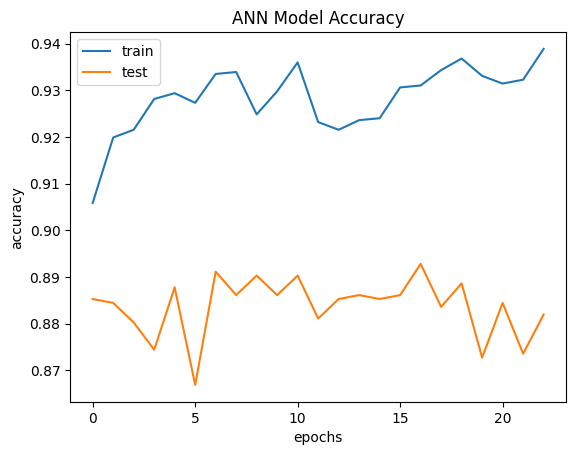

In [196]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('ANN Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

In [197]:
# For Loss

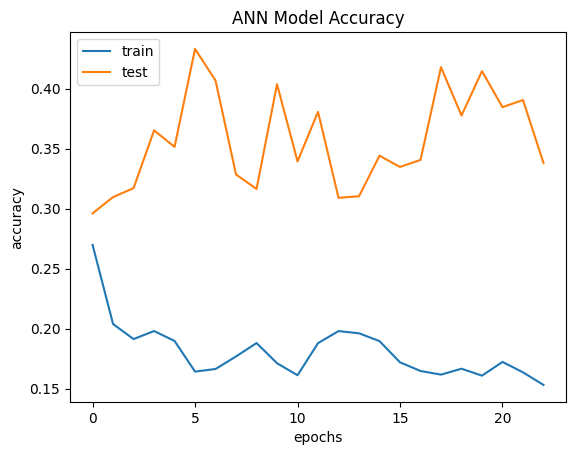

In [198]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('ANN Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

In [199]:
# Using model for test data

In [200]:
y_prd = classifier.predict(X_test)
y_prd = (y_prd > 0.5)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [201]:
# Confusion Matrixs

In [202]:
from sklearn.metrics import confusion_matrix

In [203]:
con_fus = confusion_matrix(y_test, y_prd)
con_fus

array([[807,   0],
       [ 98,   0]])

In [204]:
# Model Accuracy

In [205]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_prd, y_test)

In [206]:
score

0.8917127071823204

In [207]:
# Getting the Weights of the Trained Model

In [208]:
classifier.get_weights()

[array([[ 1.68264234e+00, -1.87295759e+00,  4.74114358e-01,
          2.29519963e+00, -1.85070932e+00,  1.45188525e-01,
          1.38133258e-01,  1.00612450e+00,  1.31332922e+00,
          1.54537964e+00,  6.78089023e-01,  9.59804118e-01,
         -1.06653416e+00, -1.39049411e-01,  1.29991722e+00,
          9.20838714e-01, -1.08715987e+00,  1.42829582e-01,
         -5.88788912e-02,  1.11720705e+00, -3.08961415e+00,
         -7.51586795e-01,  8.26476142e-03,  9.94882584e-02,
          1.29909194e+00, -1.69367814e+00, -1.10388291e+00,
         -4.91988331e-01, -8.27740192e-01],
        [ 4.49461311e-01,  4.98223871e-01,  4.55060869e-01,
          6.81689441e-01,  1.00026345e+00,  1.10267735e+00,
          9.91833985e-01, -7.90320039e-02,  4.47873145e-01,
          6.10389598e-02, -5.12360454e-01, -7.85402834e-01,
          1.12584662e+00,  1.18472600e+00, -3.30139041e-01,
          2.08747387e-03,  1.41502425e-01,  1.73125732e+00,
          7.21505642e-01, -5.05797602e-02, -3.81365091e-